In [1]:
import numpy as np 
import torch
import xarray as xr

import sys
sys.path.append('../')
import dpa_ensemble as de
import utils as ut
import evaluation
from engression.loss_func import energy_loss, energy_loss_two_sample
import matplotlib.pyplot as plt

In [41]:
settings_file_path = "/Users/friederl/Documents/EcoN_project/LLAAE/DPA/code/dpa_for_llaae/joint_training/v1_dpa_train_settings_local.json"
with open(settings_file_path, 'r') as file:
        settings = json.load(file)

ds = xr.open_dataset(settings['dataset_trefht'])
print("Dataset:", settings['dataset_trefht'])

# set train/test split
ds_train = ds.isel(time=slice(0, 4769 * 10)) #4769 * 80
ds_test = ds.isel(time=slice(4769 * 10, 476900)) #4769 * 80

print(ds_train.TREFHT.shape)
print(ds_test.TREFHT.shape)


# transform to torch tensors
x_tr = ut.data_to_torch(ds_train, "TREFHT")
x_te = ut.data_to_torch(ds_test, "TREFHT")

print(x_tr.shape)
print(x_te.shape)

# load Z500
#ds_z500_pre = xr.open_dataset(settings['dataset_z500'])
#ds_z500, _, _ = ut.standardize_numpy(ds_z500_pre.pseudo_pcs.values)
#print("z500 shape", ds_z500.shape)
#z500 = torch.from_numpy(ds_z500)
#print("z500 shape", z500.shape)


#z500_train = z500[:int(128000),:]
#z500_test = z500[int(-64000):,:]

# remove NaNs from data
x_tr_reduced, mask_x_tr = ut.remove_nan_columns(x_tr)

Dataset: /Users/friederl/Documents/EcoN_project/LLAAE/dpa_input_data/v1_until16102025/europe_10percent_masked_stacked_TREFHT_JJA.nc
(32, 32, 47690)
(32, 32, 429210)
torch.Size([47690, 1024])
torch.Size([429210, 1024])
torch.Size([47690, 1024])
torch.Size([429210, 1024])


In [4]:
import torch

def pca_reconstruct_rmse(X, n_components):
    """
    X: (n_samples, n_features) torch tensor
    n_components: number of principal components to keep
    """

    # 1. Center data
    X_mean = X.mean(dim=0)
    X_centered = X - X_mean

    # 2. PCA via SVD
    U, S, Vt = torch.linalg.svd(X_centered, full_matrices=False)

    # 3. Keep top PCs
    Vt_k = Vt[:n_components]                # (k, n_features)

    # 4. Projection
    X_proj = X_centered @ Vt_k.T           # (n_samples, k)

    # 5. Reconstruction
    X_rec = X_proj @ Vt_k + X_mean         # (n_samples, n_features)

    # 6. RMSE per sample
    mse = torch.mean((X - X_rec)**2, dim=1)  # (n_samples,)
    rmse = torch.sqrt(mse)

    return X_rec, rmse


tensor([2.8807e-06, 2.1790e-06, 2.3936e-06,  ..., 3.4484e-06, 3.9548e-06,
        4.5337e-06])
torch.Size([10, 4769])


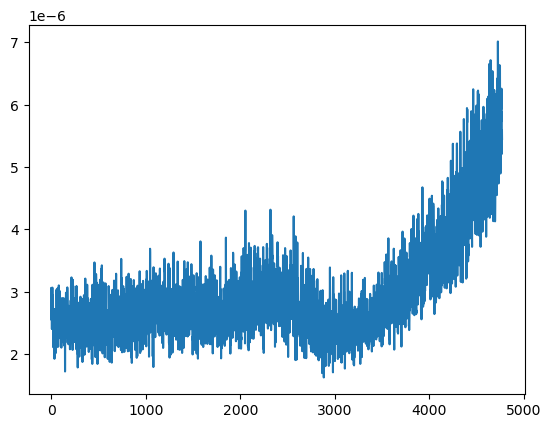

In [64]:
# all time
X = x_tr_reduced #torch.randn(100, 20)
X_rec, rmse = pca_reconstruct_rmse(X, 648)

print(rmse)   # RMSE for each sample
rmse.shape

rmse_res = rmse.reshape((10,4769))
print(rmse_res.shape)
rmse_mean = rmse_res.mean(dim=0)
rmse_mean.shape
plt.plot(rmse_mean)

torch.Size([10, 1900, 648])


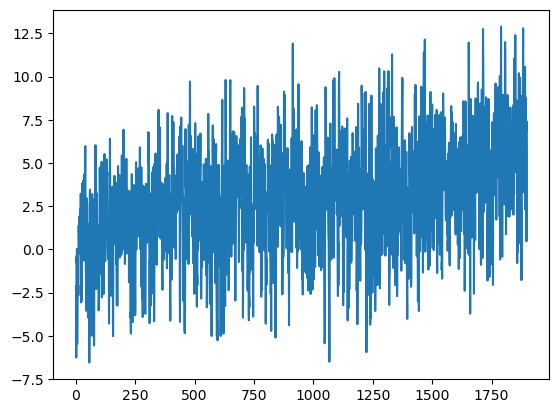

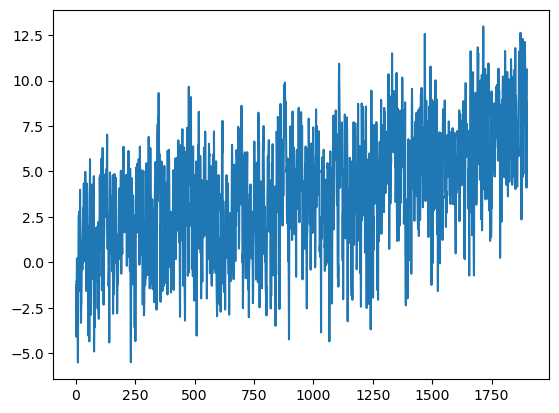

In [55]:
# only 2000 - 2100
# is this correct?
X = x_tr_reduced.reshape((10, 4769,648))[:,-1900:4769,:]
print(X.shape)
plt.plot(X[0,:,1])
plt.show()
X_re = X.reshape((19000,648))
plt.plot(X_re[:1900,100])

tensor([0.2298, 0.2324, 0.2082,  ..., 0.2771, 0.2431, 0.2132])
torch.Size([10, 1900])


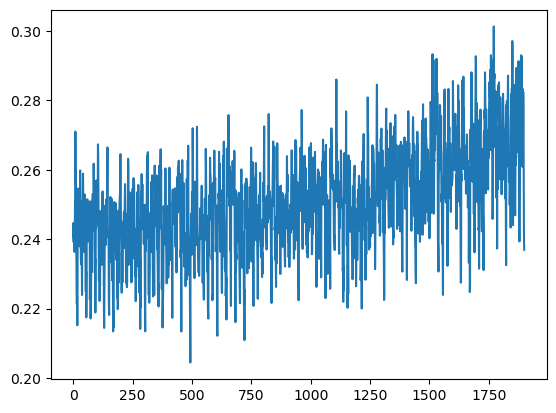

In [57]:
X_rec, rmse = pca_reconstruct_rmse(X_re, 100)

print(rmse)   # RMSE for each sample
rmse.shape

rmse_res = rmse.reshape((10,1900))
print(rmse_res.shape)
rmse_mean = rmse_res.mean(dim=0)
rmse_mean.shape
plt.plot(rmse_mean)